In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np
import hashlib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms


class MerkleTree:
    def __init__(self, data_list):
        self.leaves = sorted([hashlib.sha256(str(x).encode()).hexdigest() for x in data_list])
        self.root = self._build_tree(self.leaves)

    def _build_tree(self, nodes):
        if not nodes: return None
        if len(nodes) == 1: return nodes[0]
        new_level = []
        for i in range(0, len(nodes), 2):
            left = nodes[i]
            right = nodes[i+1] if i+1 < len(nodes) else nodes[i]
            combined = hashlib.sha256((left + right).encode()).hexdigest()
            new_level.append(combined)
        return self._build_tree(new_level)

class NIHDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.labels = self.df['Finding Labels'].unique().tolist()
        self.label_map = {label: idx for idx, label in enumerate(self.labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image Index'])
        image = Image.open(img_path).convert('L')
        label_idx = self.label_map[row['Finding Labels']]
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label_idx)

class Generator(nn.Module):
    def __init__(self, n_classes, latent_dim=100, img_size=1024):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        self.init_size = img_size // 4
        self.l1 = nn.Sequential(nn.Linear(latent_dim + n_classes, 128 * self.init_size**2))
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 1, 3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, noise, labels):
        gen_input = torch.cat((self.label_emb(labels), noise), -1)
        out = self.l1(gen_input)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

class Discriminator(nn.Module):
    def __init__(self, n_classes, img_size=1024):
        super(Discriminator, self).__init__()
        self.label_embedding = nn.Embedding(n_classes, n_classes)
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        ds_size = img_size // 2**4
        self.adv_layer = nn.Sequential(
            nn.Linear(512 * ds_size ** 2 + n_classes, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        features = self.model(img)
        features = features.view(features.shape[0], -1)
        label_emb = self.label_embedding(labels)
        d_in = torch.cat((features, label_emb), -1)
        validity = self.adv_layer(d_in)
        return validity

class SISA_Pipeline:
    def __init__(self, csv_path, img_dir, num_shards=5, limit=4999):
        self.img_dir = img_dir
        self.num_shards = num_shards
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Load Data
        full_df = pd.read_csv(csv_path).head(limit)
        patient_ids = full_df['Patient ID'].unique()
        shard_assignments = np.array_split(patient_ids, num_shards)

        self.shards = {}
        self.generators = {}
        self.discriminators = {}
        self.merkle_roots = {}

        self.n_classes = len(full_df['Finding Labels'].unique())

        print(f"Initializing {num_shards} Shards on {self.device}...")
        for i, patients in enumerate(shard_assignments):
            shard_df = full_df[full_df['Patient ID'].isin(patients)].copy()
            self.shards[i] = shard_df

            # Merkle Tree
            tree = MerkleTree(shard_df['Image Index'].tolist())
            self.merkle_roots[i] = tree.root

            # Initialize Networks
            self.generators[i] = Generator(n_classes=self.n_classes).to(self.device)
            self.discriminators[i] = Discriminator(n_classes=self.n_classes).to(self.device)

            print(f"  > Shard {i}: {len(shard_df)} images initialized.")

    def train_shard(self, shard_id, epochs=300):
        print(f"\n[Training] Starting training for Shard {shard_id} for {epochs} epochs...")

        dataset = NIHDataset(self.shards[shard_id], self.img_dir,
                           transform=transforms.Compose([
                               transforms.Resize((128, 128)),
                               transforms.ToTensor(),
                               transforms.Normalize([0.5], [0.5])
                           ]))
        dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

        generator = self.generators[shard_id]
        discriminator = self.discriminators[shard_id]

        adversarial_loss = torch.nn.BCELoss()
        optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
        optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

        for epoch in range(epochs):
            for i, (imgs, labels) in enumerate(dataloader):
                real_imgs = imgs.to(self.device)
                labels = labels.to(self.device)
                batch_size = imgs.shape[0]

                valid = torch.ones(batch_size, 1).to(self.device)
                fake = torch.zeros(batch_size, 1).to(self.device)


                optimizer_G.zero_grad()
                z = torch.randn(batch_size, 100).to(self.device)
                gen_imgs = generator(z, labels)
                validity = discriminator(gen_imgs, labels)
                g_loss = adversarial_loss(validity, valid)
                g_loss.backward()
                optimizer_G.step()

                optimizer_D.zero_grad()
                real_pred = discriminator(real_imgs, labels)
                d_real_loss = adversarial_loss(real_pred, valid)
                fake_pred = discriminator(gen_imgs.detach(), labels)
                d_fake_loss = adversarial_loss(fake_pred, fake)
                d_loss = (d_real_loss + d_fake_loss) / 2
                d_loss.backward()
                optimizer_D.step()

            if epoch % 50 == 0:
                print(f"[Epoch {epoch}/{epochs}] [D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

        print(f"[Training] Shard {shard_id} complete.")

    def unlearn_patient(self, patient_id):
        target_shard = -1

        for s_id, df in self.shards.items():
            if patient_id in df['Patient ID'].values:
                target_shard = s_id
                break

        if target_shard == -1:
            print(f"Patient {patient_id} not found.")
            return

        print(f"\n--- Unlearning Request: Patient {patient_id} (Shard {target_shard}) ---")


        self.shards[target_shard] = self.shards[target_shard][self.shards[target_shard]['Patient ID'] != patient_id]


        new_tree = MerkleTree(self.shards[target_shard]['Image Index'].tolist())
        old_root = self.merkle_roots[target_shard]
        self.merkle_roots[target_shard] = new_tree.root

        print(f"Old Root: {old_root[:15]}...")
        print(f"New Root: {new_tree.root[:15]}...")

        if old_root != new_tree.root:
            print(" Data lineage has changed.")


        print(f"Resetting Models for Shard {target_shard}...")
        self.generators[target_shard] = Generator(n_classes=self.n_classes).to(self.device)
        self.discriminators[target_shard] = Discriminator(n_classes=self.n_classes).to(self.device)
        self.train_shard(target_shard)

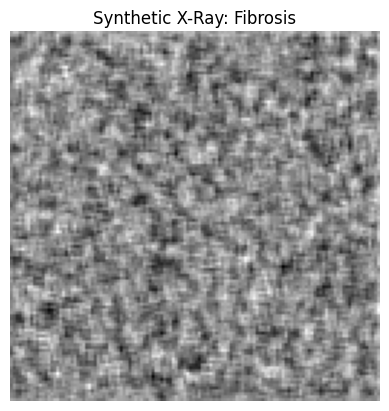

In [ ]:
import torch
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sisa.generators[0].to(device)
sisa.generators[0].eval()


target_disease = "Fibrosis"
shard0_dataset = NIHDataset(sisa.shards[0], sisa.img_dir)

if target_disease in shard0_dataset.label_map:
    disease_id = shard0_dataset.label_map[target_disease]


    label_input = torch.tensor([disease_id]).to(device)


    noise_input = torch.randn(1, 100).to(device)


    with torch.no_grad():

        generated_tensor = sisa.generators[0](noise_input, label_input)


    img_data = generated_tensor.cpu().squeeze(0).squeeze(0).numpy()

    plt.imshow(img_data, cmap='gray')
    plt.title(f"Synthetic X-Ray: {target_disease}")
    plt.axis('off')
    plt.show()

else:
    print(f"Error: '{target_disease}' is not in Shard 0's label map.")
    print("Available labels in Shard 0:", list(shard0_dataset.label_map.keys())[:5])